# Model Development & Tracking
## Stage 3 · baseline + advanced models, MLflow tracking & registry  <font color="red">[30 marks]</font>

- Each stage lists its **sub-tasks as a checklist**
- Complete every `# TODO`; implement the training logic in `src/train.py` (metrics helper provided in `src/evaluate.py`) and call it here.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`
- *Provided to extend:* `src/train.py`. 
- *You create:* the cells below.

## Stage 3.1 — Baseline Model (Logistic Regression) <font color="red">[5 marks]</font>

- **3.1.1 — Logistic Regression baseline trained (Pipeline, imbalance handled) [3]** — `LogisticRegression(class_weight='balanced')` as a full Pipeline (preprocess + classify), fit on train.
- **3.1.2 — Baseline evaluated on validation [2]** — report imbalance-aware validation metrics (ROC-AUC / PR-AUC / recall).

In [11]:

import warnings; warnings.filterwarnings('ignore')
import mlflow, config as cfg
# TODO 3.1.1...
# TODO 3.1.1: build & fit the LogReg baseline Pipeline (class_weight='balanced').
# TODO 3.1.2: evaluate it on the validation split and print the metrics.


# Stage 3.1 — Baseline Model: Logistic Regression


import warnings
warnings.filterwarnings("ignore")

import importlib
import pandas as pd
import mlflow
import config as cfg

from src import data_prep as dp
from src import train as tr


# Reload project modules in case they were edited in VS Code
importlib.reload(dp)
importlib.reload(tr)



# Load modelling frame and reproduce Stage 2 splits


model_df = dp.get_model_frame()

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = dp.get_splits(model_df)


print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)



# Identify numeric and categorical feature columns


numeric_cols, categorical_cols = (
    dp.get_feature_lists(X_train)
)


print("\nNumeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))



# 3.1.1 — Build Logistic Regression FULL Pipeline


logreg_model = tr.build_logreg_pipeline(
    numeric_cols,
    categorical_cols
)


print("\nLogistic Regression Pipeline:")
print(logreg_model)



# Fit ONLY on training data


logreg_model.fit(
    X_train,
    y_train
)


print("\nLogistic Regression training complete.")



# Confirm pipeline components


print("\nPipeline steps:")
print(
    list(
        logreg_model.named_steps.keys()
    )
)


print(
    "\nClassifier:",
    logreg_model
    .named_steps["classifier"]
)


print(
    "\nClass weight:",
    logreg_model
    .named_steps["classifier"]
    .class_weight
)



# 3.1.2 — Evaluate on VALIDATION data


(
    logreg_val_prob,
    logreg_val_metrics
) = tr.evaluate_model(
    logreg_model,
    X_val,
    y_val
)


print("\nValidation Metrics:")

for metric, value in logreg_val_metrics.items():
    print(
        f"{metric:<10}: {value:.4f}"
    )



# Compact metric table


logreg_metrics_table = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            **logreg_val_metrics
        }
    ]
)

print("\nBaseline Validation Summary:")
display(logreg_metrics_table)

Training shape: (44782, 39)
Validation shape: (11196, 39)
Test shape: (13995, 39)

Numeric features: 11
Categorical features: 28

Logistic Regression Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                       

,Model,roc_auc,pr_auc,f1,recall,precision,accuracy
0,Logistic Regression,0.6532,0.1689,0.2263,0.5388,0.1432,0.6696


## Stage 3.2 — Advanced Model (XGBoost) <font color="red">[8 marks]</font>

- **3.2.1 — XGBoost trained (Pipeline, `scale_pos_weight` imbalance handled) [5]** — XGBoost with `scale_pos_weight = neg/pos` as a full Pipeline, fit on train.
- **3.2.2 — Advanced model evaluated on validation [3]** — report the same validation metrics for comparison with the baseline.

In [12]:
# TODO 3.2.1: build & fit the XGBoost Pipeline (scale_pos_weight = neg/pos).
# TODO 3.2.2: evaluate it on the validation split and print the metrics.



# Stage 3.2 — Advanced Model: XGBoost


# Reload train.py after adding the XGBoost helper
importlib.reload(tr)



# 3.2.1 — Calculate imbalance weight FROM TRAINING DATA ONLY


negative_count = int(
    (y_train == 0).sum()
)

positive_count = int(
    (y_train == 1).sum()
)


scale_pos_weight = (
    negative_count / positive_count
)


print("Training class counts:")
print("Negative:", negative_count)
print("Positive:", positive_count)

print(
    "\nscale_pos_weight:",
    round(scale_pos_weight, 4)
)



# Build FULL XGBoost Pipeline


xgb_model = tr.build_xgb_pipeline(
    numeric_cols,
    categorical_cols,
    scale_pos_weight
)


print("\nXGBoost Pipeline:")
print(xgb_model)



# Confirm model configuration


xgb_classifier = (
    xgb_model.named_steps["classifier"]
)


print("\nPipeline steps:")
print(
    list(
        xgb_model.named_steps.keys()
    )
)


print(
    "\nXGBoost scale_pos_weight:",
    xgb_classifier.scale_pos_weight
)


print("\nXGBoost parameters:")

print(
    {
        "n_estimators": xgb_classifier.n_estimators,
        "max_depth": xgb_classifier.max_depth,
        "learning_rate": xgb_classifier.learning_rate,
        "subsample": xgb_classifier.subsample,
        "colsample_bytree": xgb_classifier.colsample_bytree,
        "random_state": xgb_classifier.random_state,
        "eval_metric": xgb_classifier.eval_metric,
        "tree_method": xgb_classifier.tree_method
    }
)



# Train on TRAINING data only


xgb_model.fit(
    X_train,
    y_train
)


print("\nXGBoost training complete.")



# 3.2.2 — Evaluate on VALIDATION data


(
    xgb_val_prob,
    xgb_val_metrics
) = tr.evaluate_model(
    xgb_model,
    X_val,
    y_val
)


print("\nXGBoost Validation Metrics:")

for metric, value in xgb_val_metrics.items():

    print(
        f"{metric:<10}: {value:.4f}"
    )



# Compact validation summary


xgb_metrics_table = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            **xgb_val_metrics
        }
    ]
)


print("\nXGBoost Validation Summary:")

display(
    xgb_metrics_table
)

Training class counts:
Negative: 40764
Positive: 4018

scale_pos_weight: 10.1453

XGBoost Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                            

,Model,roc_auc,pr_auc,f1,recall,precision,accuracy
0,XGBoost,0.6499,0.1737,0.2301,0.4542,0.1541,0.7275


## Stage 3.3 — Model Evaluation <font color="red">[5 marks]</font>

- **3.3.1 — Imbalance-aware metrics + model selection [3]** — ROC-AUC, PR-AUC, recall, precision, F1 for both models in a comparison table; select on ROC-AUC.
- **3.3.2 — Plots + interpretation (why accuracy misleads) [2]** — ROC + confusion plots; explain why accuracy is misleading at ~9% prevalence.

Validation Model Comparison:


,Model,roc_auc,pr_auc,recall,precision,f1,accuracy
0,Logistic Regression,0.6532,0.1689,0.5388,0.1432,0.2263,0.6696
1,XGBoost,0.6499,0.1737,0.4542,0.1541,0.2301,0.7275



Model Selection Metric: ROC-AUC
Logistic Regression ROC-AUC: 0.6532
XGBoost ROC-AUC: 0.6499

Selected Final Model: Logistic Regression
Selected Validation ROC-AUC: 0.6532

Validation Metric Trade-off:
Logistic Regression Recall: 0.5388
XGBoost Recall: 0.4542
Logistic Regression PR-AUC: 0.1689
XGBoost PR-AUC: 0.1737


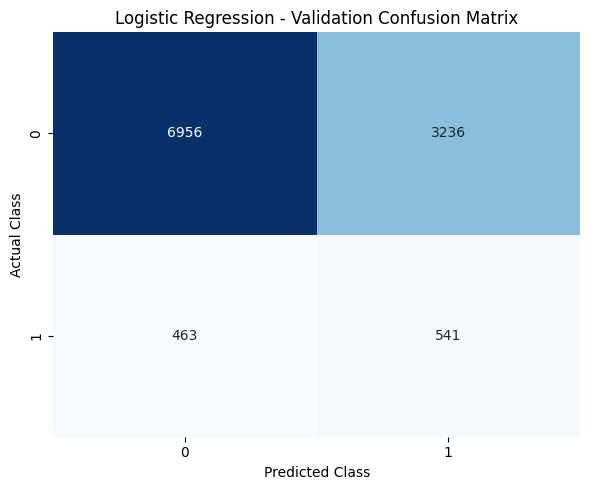

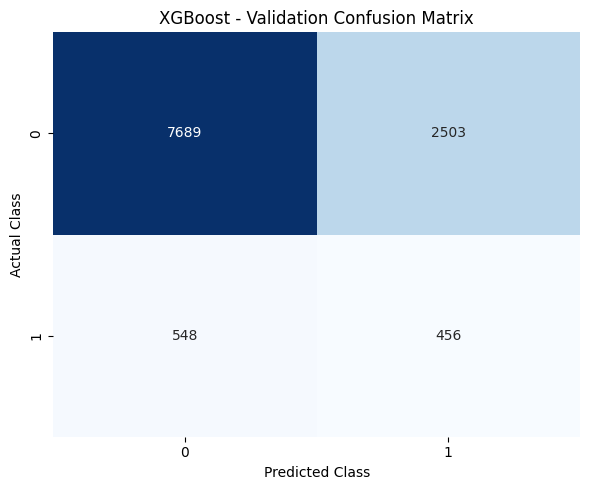

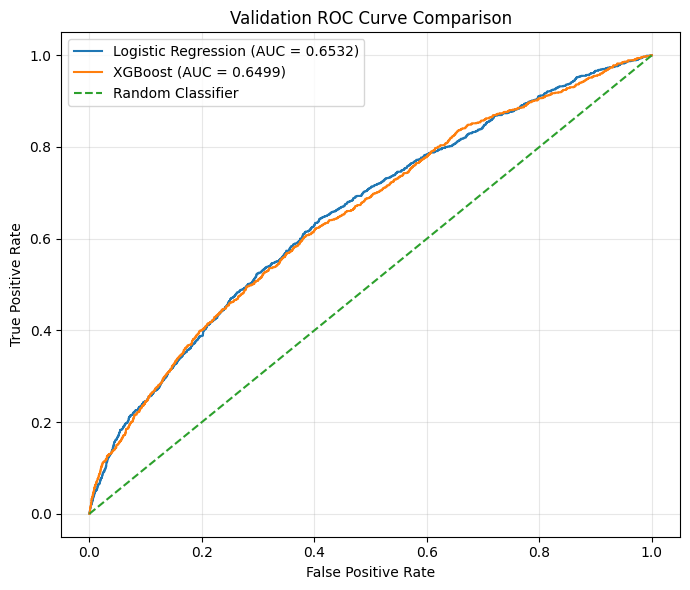


Logistic Regression Confusion Matrix:
{'TN': 6956, 'FP': 3236, 'FN': 463, 'TP': 541}

XGBoost Confusion Matrix:
{'TN': 7689, 'FP': 2503, 'FN': 548, 'TP': 456}

Majority-class baseline accuracy: 0.9103

Interpretation:
Accuracy is not appropriate as the primary model-selection metric because approximately 91% of observations belong to the negative class.
A model predicting every patient as not readmitted could achieve approximately 91% accuracy while identifying none of the true 30-day readmissions.
Therefore ROC-AUC is used for final model selection, while PR-AUC, recall, precision and F1 are also reported to evaluate performance on the minority readmission class.


In [13]:
# TODO 3.3.1: build the metric comparison table and select the best model on ROC-AUC.
# TODO 3.3.2: plot ROC + confusion for the best model; add a written interpretation.



# Stage 3.3 — Model Evaluation and Selection


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)



# 3.3.1 — Compare validation metrics


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            **logreg_val_metrics
        },
        {
            "Model": "XGBoost",
            **xgb_val_metrics
        }
    ]
)


# Arrange columns for readability
metric_columns = [
    "Model",
    "roc_auc",
    "pr_auc",
    "recall",
    "precision",
    "f1",
    "accuracy"
]

comparison_df = comparison_df[
    metric_columns
]


print("Validation Model Comparison:")

display(
    comparison_df.round(4)
)



# Select final model using VALIDATION ROC-AUC


logreg_auc = logreg_val_metrics["roc_auc"]

xgb_auc = xgb_val_metrics["roc_auc"]


if logreg_auc >= xgb_auc:

    best_model_name = "Logistic Regression"

    best_model = logreg_model

    best_val_prob = logreg_val_prob

    best_val_metrics = logreg_val_metrics

else:

    best_model_name = "XGBoost"

    best_model = xgb_model

    best_val_prob = xgb_val_prob

    best_val_metrics = xgb_val_metrics


print("\nModel Selection Metric: ROC-AUC")

print(
    f"Logistic Regression ROC-AUC: "
    f"{logreg_auc:.4f}"
)

print(
    f"XGBoost ROC-AUC: "
    f"{xgb_auc:.4f}"
)


print(
    "\nSelected Final Model:",
    best_model_name
)


print(
    "Selected Validation ROC-AUC:",
    round(
        best_val_metrics["roc_auc"],
        4
    )
)



# Explain other metric trade-offs


print("\nValidation Metric Trade-off:")

print(
    f"Logistic Regression Recall: "
    f"{logreg_val_metrics['recall']:.4f}"
)

print(
    f"XGBoost Recall: "
    f"{xgb_val_metrics['recall']:.4f}"
)

print(
    f"Logistic Regression PR-AUC: "
    f"{logreg_val_metrics['pr_auc']:.4f}"
)

print(
    f"XGBoost PR-AUC: "
    f"{xgb_val_metrics['pr_auc']:.4f}"
)



# 3.3.2 — Confusion Matrix


# Standard classification threshold
threshold = 0.50


logreg_val_pred = (
    logreg_val_prob >= threshold
).astype(int)


xgb_val_pred = (
    xgb_val_prob >= threshold
).astype(int)



# Logistic Regression confusion matrix


logreg_cm = confusion_matrix(
    y_val,
    logreg_val_pred
)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    logreg_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Logistic Regression - Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()

plt.show()



# XGBoost confusion matrix


xgb_cm = confusion_matrix(
    y_val,
    xgb_val_pred
)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "XGBoost - Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()

plt.show()



# ROC Curve Comparison


logreg_fpr, logreg_tpr, _ = roc_curve(
    y_val,
    logreg_val_prob
)


xgb_fpr, xgb_tpr, _ = roc_curve(
    y_val,
    xgb_val_prob
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(
    logreg_fpr,
    logreg_tpr,
    label=(
        f"Logistic Regression "
        f"(AUC = {logreg_auc:.4f})"
    )
)


plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=(
        f"XGBoost "
        f"(AUC = {xgb_auc:.4f})"
    )
)


# Random-classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Validation ROC Curve Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()



# Confusion-matrix values for interpretation


logreg_tn, logreg_fp, logreg_fn, logreg_tp = (
    logreg_cm.ravel()
)

xgb_tn, xgb_fp, xgb_fn, xgb_tp = (
    xgb_cm.ravel()
)


print("\nLogistic Regression Confusion Matrix:")

print(
    {
        "TN": int(logreg_tn),
        "FP": int(logreg_fp),
        "FN": int(logreg_fn),
        "TP": int(logreg_tp)
    }
)


print("\nXGBoost Confusion Matrix:")

print(
    {
        "TN": int(xgb_tn),
        "FP": int(xgb_fp),
        "FN": int(xgb_fn),
        "TP": int(xgb_tp)
    }
)



# Why accuracy is misleading


majority_baseline_accuracy = (
    (y_val == 0).mean()
)


print(
    "\nMajority-class baseline accuracy:",
    f"{majority_baseline_accuracy:.4f}"
)


print(
    "\nInterpretation:"
)

print(
    "Accuracy is not appropriate as the primary model-selection "
    "metric because approximately 91% of observations belong "
    "to the negative class."
)

print(
    "A model predicting every patient as not readmitted could "
    "achieve approximately 91% accuracy while identifying "
    "none of the true 30-day readmissions."
)

print(
    "Therefore ROC-AUC is used for final model selection, "
    "while PR-AUC, recall, precision and F1 are also reported "
    "to evaluate performance on the minority readmission class."
)

## Stage 3.4 — MLflow Experiment Tracking <font color="red">[7 marks]</font>

- **3.4.1 — Both runs logged with params + metrics + model [4]** — set tracking URI + experiment; for each model log params, metrics and the model artefact.
- **3.4.2 — Runs compared (search_runs table) [3]** — compare the runs with `mlflow.search_runs(...)` and state the selection criterion.

In [14]:
# TODO 3.4.1: log both runs (params + metrics + model) to an MLflow experiment.
# TODO 3.4.2: compare the runs with mlflow.search_runs(...).




# Stage 3.4 — MLflow Experiment Tracking


import mlflow
import mlflow.sklearn



# 3.4.1 — Configure MLflow


mlflow.set_tracking_uri(
    cfg.MLFLOW_TRACKING_URI
)

mlflow.set_experiment(
    cfg.MLFLOW_EXPERIMENT
)


print(
    "MLflow Tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "MLflow Experiment:",
    cfg.MLFLOW_EXPERIMENT
)



# Log Logistic Regression run


with mlflow.start_run(
    run_name="logistic_regression_baseline"
) as logreg_run:

    
    # Parameters
    

    mlflow.log_params(
        {
            "model_type": "LogisticRegression",
            "class_weight": "balanced",
            "max_iter": 1000,
            "random_state": cfg.RANDOM_STATE
        }
    )


    
    # Validation metrics
    

    mlflow.log_metrics(
        {
            f"val_{metric}": float(value)
            for metric, value
            in logreg_val_metrics.items()
        }
    )


    
    # Log COMPLETE sklearn Pipeline
    # preprocessing + classifier
    

    mlflow.sklearn.log_model(
        sk_model=logreg_model,
        artifact_path="model"
    )


    logreg_run_id = (
        logreg_run.info.run_id
    )


print(
    "\nLogistic Regression run ID:",
    logreg_run_id
)



# Log XGBoost run


with mlflow.start_run(
    run_name="xgboost_advanced"
) as xgb_run:

    
    # Parameters
    

    mlflow.log_params(
        {
            "model_type": "XGBoost",
            "scale_pos_weight": float(
                scale_pos_weight
            ),
            "n_estimators":
                cfg.XGB_PARAMS["n_estimators"],
            "max_depth":
                cfg.XGB_PARAMS["max_depth"],
            "learning_rate":
                cfg.XGB_PARAMS["learning_rate"],
            "subsample":
                cfg.XGB_PARAMS["subsample"],
            "colsample_bytree":
                cfg.XGB_PARAMS["colsample_bytree"],
            "random_state":
                cfg.XGB_PARAMS["random_state"],
            "eval_metric":
                cfg.XGB_PARAMS["eval_metric"],
            "tree_method":
                cfg.XGB_PARAMS["tree_method"]
        }
    )


    
    # Validation metrics
    

    mlflow.log_metrics(
        {
            f"val_{metric}": float(value)
            for metric, value
            in xgb_val_metrics.items()
        }
    )


    
    # Log COMPLETE XGBoost sklearn Pipeline
    

    mlflow.sklearn.log_model(
        sk_model=xgb_model,
        artifact_path="model"
    )


    xgb_run_id = (
        xgb_run.info.run_id
    )


print(
    "XGBoost run ID:",
    xgb_run_id
)



# 3.4.2 — Compare MLflow runs


experiment = (
    mlflow.get_experiment_by_name(
        cfg.MLFLOW_EXPERIMENT
    )
)


runs_df = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ]
)


# Select useful columns
comparison_columns = [
    "run_id",
    "tags.mlflow.runName",
    "params.model_type",
    "metrics.val_roc_auc",
    "metrics.val_pr_auc",
    "metrics.val_recall",
    "metrics.val_precision",
    "metrics.val_f1",
    "metrics.val_accuracy"
]


available_columns = [
    col
    for col in comparison_columns
    if col in runs_df.columns
]


mlflow_comparison = (
    runs_df[available_columns]
    .sort_values(
        by="metrics.val_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nMLflow Run Comparison:"
)

display(
    mlflow_comparison
)



# Confirm MLflow model-selection criterion


mlflow_best_run = (
    mlflow_comparison.iloc[0]
)


print(
    "\nSelection Criterion:"
    " Validation ROC-AUC"
)


print(
    "Best MLflow Run:",
    mlflow_best_run[
        "tags.mlflow.runName"
    ]
)


print(
    "Best Validation ROC-AUC:",
    round(
        mlflow_best_run[
            "metrics.val_roc_auc"
        ],
        4
    )
)


print(
    "\nExpected selected model from Stage 3.3:",
    best_model_name
)

2026/08/13 00:08:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow Tracking URI: sqlite:///mlflow.db
MLflow Experiment: hospital_readmission


2026/08/13 00:08:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/13 00:08:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logistic Regression run ID: 092bca4e6c6946d484149e143e9a9739


2026/08/13 00:08:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost run ID: d5e2781ce9d341bb944d3608f3d253c2

MLflow Run Comparison:


,run_id,tags.mlflow.runName,params.model_type,metrics.val_roc_auc,metrics.val_pr_auc,metrics.val_recall,metrics.val_precision,metrics.val_f1,metrics.val_accuracy
0,092bca4e6c6946d484149e143e9a9739,logistic_regression_baseline,LogisticRegression,0.6532,0.1689,0.5388,0.1432,0.2263,0.6696
1,abf7a6938acc4fe4b04d0b6587eeff99,logistic_regression_baseline,LogisticRegression,0.6532,0.1689,0.5388,0.1432,0.2263,0.6696
2,4e874763efae44e5aa7c47026c102ddc,logistic_regression_baseline,LogisticRegression,0.6532,0.1689,0.5388,0.1432,0.2263,0.6696
3,d5e2781ce9d341bb944d3608f3d253c2,xgboost_advanced,XGBoost,0.6499,0.1737,0.4542,0.1541,0.2301,0.7275
4,9eb5fa892a9f45a0a490fb90e77faad2,xgboost_advanced,XGBoost,0.6499,0.1737,0.4542,0.1541,0.2301,0.7275
5,b0b73d04197045c4bee6000bbb2f823b,xgboost_advanced,XGBoost,0.6499,0.1737,0.4542,0.1541,0.2301,0.7275



Selection Criterion: Validation ROC-AUC
Best MLflow Run: logistic_regression_baseline
Best Validation ROC-AUC: 0.6532

Expected selected model from Stage 3.3: Logistic Regression


## Stage 3.5 — Model Registry & Versioning <font color="red">[5 marks]</font>

- **3.5.1 — Best model registered in the MLflow Model Registry [2]** — `mlflow.register_model` for the best model.
- **3.5.2 — Promotion to production alias + version history [3]** — promote to the `production` alias and show the version history.

In [15]:
# TODO 3.5.1: register the best model (by val ROC-AUC) with mlflow.register_model.
# TODO 3.5.2: promote it to the 'production' alias and print the version history.



# Stage 3.5 — Model Registry & Versioning

from mlflow import MlflowClient



# 3.5.1 — Identify the winning MLflow run


if best_model_name == "Logistic Regression":

    best_run_id = logreg_run_id

else:

    best_run_id = xgb_run_id


print("Selected Model:")
print(best_model_name)

print("\nSelected MLflow Run ID:")
print(best_run_id)



# Build URI of the already-logged winning model


best_model_uri = (
    f"runs:/{best_run_id}/model"
)


print("\nWinning Model URI:")
print(best_model_uri)



# Register selected model


registered_version = mlflow.register_model(
    model_uri=best_model_uri,
    name=cfg.REGISTERED_MODEL
)


registered_version_number = (
    registered_version.version
)


print("\nRegistered Model Name:")
print(cfg.REGISTERED_MODEL)

print("\nRegistered Model Version:")
print(registered_version_number)



# 3.5.2 — Promote registered version to production alias


client = MlflowClient()


client.set_registered_model_alias(
    name=cfg.REGISTERED_MODEL,
    alias="production",
    version=registered_version_number
)


print(
    "\nAlias assigned successfully:"
)

print(
    f"{cfg.REGISTERED_MODEL}@production "
    f"-> version {registered_version_number}"
)



# Verify production alias


production_version = (
    client.get_model_version_by_alias(
        name=cfg.REGISTERED_MODEL,
        alias="production"
    )
)


print("\nProduction Alias Verification:")

print(
    "Model:",
    production_version.name
)

print(
    "Version:",
    production_version.version
)

print(
    "Run ID:",
    production_version.run_id
)

print(
    "Aliases:",
    production_version.aliases
)



# Display model-version history


model_versions = (
    client.search_model_versions(
        filter_string=(
            f"name='{cfg.REGISTERED_MODEL}'"
        )
    )
)


version_history = pd.DataFrame(
    [
        {
            "Model Name": mv.name,
            "Version": mv.version,
            "Run ID": mv.run_id,
            "Status": mv.status,
            "Aliases": ", ".join(mv.aliases)
                if mv.aliases else ""
        }
        for mv in model_versions
    ]
)


if not version_history.empty:

    version_history["Version_numeric"] = (
        pd.to_numeric(
            version_history["Version"]
        )
    )

    version_history = (
        version_history
        .sort_values(
            "Version_numeric",
            ascending=False
        )
        .drop(
            columns=["Version_numeric"]
        )
        .reset_index(drop=True)
    )


print("\nRegistered Model Version History:")

display(
    version_history
)



# Verify that model can be addressed using production alias


production_model_uri = (
    f"models:/{cfg.REGISTERED_MODEL}@production"
)


print("\nProduction Model URI:")
print(production_model_uri)


production_model = (
    mlflow.sklearn.load_model(
        production_model_uri
    )
)


print(
    "\nProduction model loaded successfully:",
    type(production_model).__name__
)



# Final registry consistency check


alias_points_to_selected_run = (
    production_version.run_id
    == best_run_id
)


print(
    "\nProduction alias points to selected winning run:",
    alias_points_to_selected_run
)

Registered model 'readmission_classifier' already exists. Creating a new version of this model...
2026/08/13 00:08:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 092bca4e6c6946d484149e143e9a9739 has no artifacts at artifact path 'model', registering model based on models:/m-84f94d7012d642399455c28d4da3e4e0 instead


Selected Model:
Logistic Regression

Selected MLflow Run ID:
092bca4e6c6946d484149e143e9a9739

Winning Model URI:
runs:/092bca4e6c6946d484149e143e9a9739/model

Registered Model Name:
readmission_classifier

Registered Model Version:
3

Alias assigned successfully:
readmission_classifier@production -> version 3

Production Alias Verification:
Model: readmission_classifier
Version: 3
Run ID: 092bca4e6c6946d484149e143e9a9739
Aliases: ['production']

Registered Model Version History:


Created version '3' of model 'readmission_classifier'.


,Model Name,Version,Run ID,Status,Aliases
0,readmission_classifier,3,092bca4e6c6946d484149e143e9a9739,READY,
1,readmission_classifier,2,abf7a6938acc4fe4b04d0b6587eeff99,READY,
2,readmission_classifier,1,4e874763efae44e5aa7c47026c102ddc,READY,



Production Model URI:
models:/readmission_classifier@production

Production model loaded successfully: Pipeline

Production alias points to selected winning run: True


### ✍️ Findings
*TODO: which model won and why? Why is accuracy misleading here?*